# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import nltk

df = pd.read_csv('RickAndMortyScripts.csv')


print(df.head())


   index  season no.  episode no. episode name   name  \
0      0           1            1        Pilot   Rick   
1      1           1            1        Pilot  Morty   
2      2           1            1        Pilot   Rick   
3      3           1            1        Pilot  Morty   
4      4           1            1        Pilot   Rick   

                                                line  
0  Morty! You gotta come on. Jus'... you gotta co...  
1                       What, Rick? What’s going on?  
2                   I got a surprise for you, Morty.  
3  It's the middle of the night. What are you tal...  
4  Come on, I got a surprise for you.  Come on, h...  


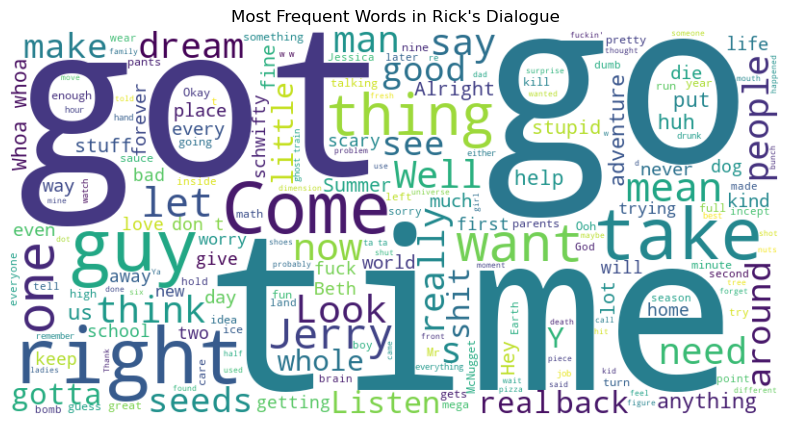

In [7]:
# Filter the DataFrame to only include lines spoken by Rick
rick_lines = df[df['name'] == 'Rick']['line']

# Join all of Rick's lines into a single string
rick_text = ' '.join(rick_lines)

# Define words to exclude from the word cloud
# Add character names to the default list of stop words
stopwords = set(STOPWORDS)
stopwords.update(["Rick", "Morty", "gonna", "uh", "oh", "yeah", "know"])

# Create the word cloud object
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(rick_text)

# Display the generated image
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Rick's Dialogue")
plt.show()

This word cloud highlights the most frequently used words in Rick’s dialogue, with larger words representing higher frequency. Terms such as ‘just,’ ‘come,’ and ‘right’ stand out, reflecting Rick’s impatient and directive speech patterns. By visualizing his vocabulary in this way, the figure captures an important aspect of his character: his tendency toward urgency, command, and repetition.

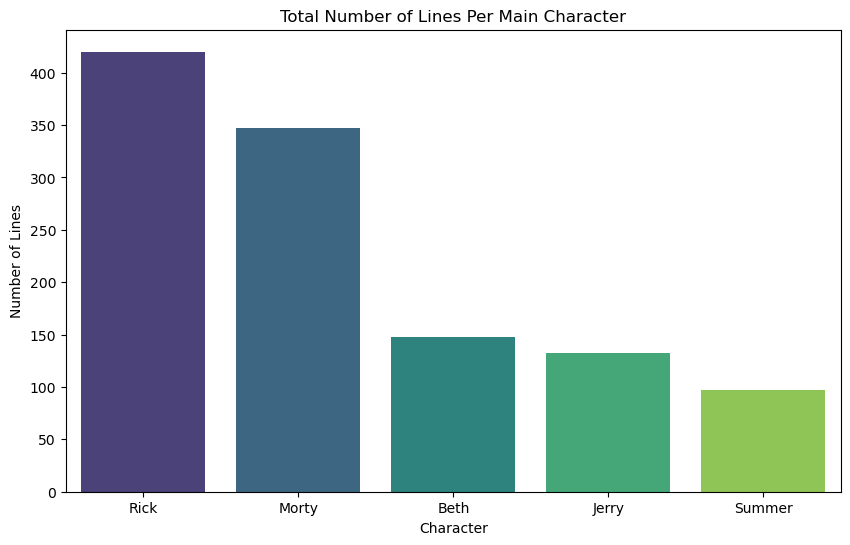

In [10]:
# Get the line counts for the main characters
main_characters = ['Rick', 'Morty', 'Summer', 'Beth', 'Jerry']
character_lines = df[df['name'].isin(main_characters)]['name'].value_counts()

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=character_lines.index, y=character_lines.values, hue=character_lines.index, palette='viridis', legend=False)

# Add titles and labels
plt.title('Total Number of Lines Per Main Character')
plt.xlabel('Character')
plt.ylabel('Number of Lines')
plt.show()

This bar chart compares the total number of lines spoken by the main characters. As expected, Rick and Morty dominate the dialogue, which reinforces their role as the focal point of the series. The figure also highlights the narrative imbalance, showing that secondary characters such as Beth, Jerry, and Summer contribute significantly less dialogue. This contrast illustrates how the show emphasizes the perspectives of the two leads while using supporting characters more sparingly.

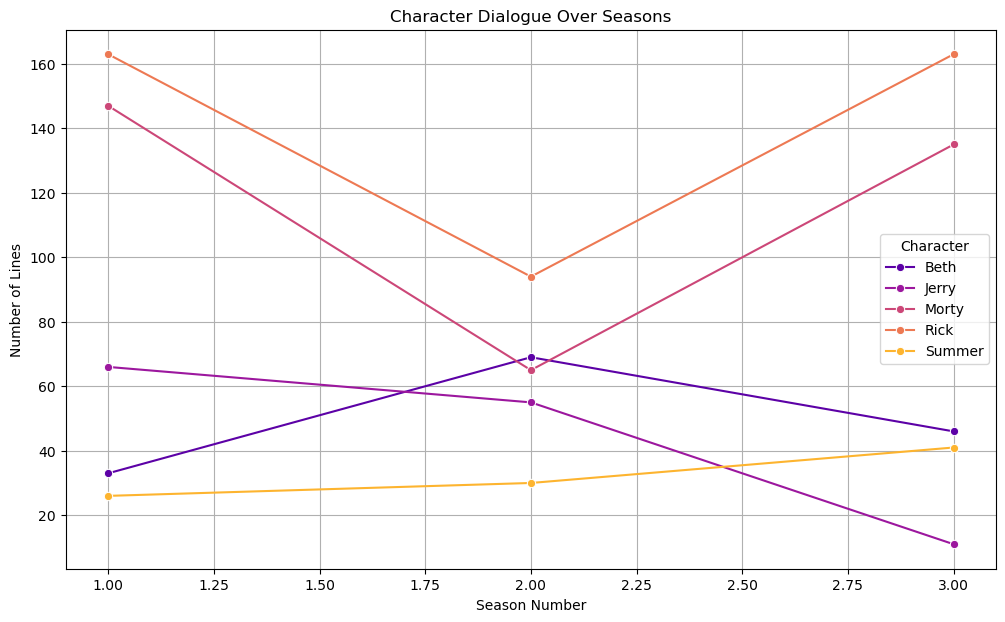

In [11]:
# Filter for main characters
main_df = df[df['name'].isin(main_characters)]

# Group by season and character, then count the lines
season_lines = main_df.groupby(['season no.', 'name']).size().reset_index(name='line_count')

# Create the line plot
plt.figure(figsize=(12, 7))
sns.lineplot(data=season_lines, x='season no.', y='line_count', hue='name', marker='o', palette='plasma')

# Add titles and labels
plt.title('Character Dialogue Over Seasons')
plt.xlabel('Season Number')
plt.ylabel('Number of Lines')
plt.legend(title='Character')
plt.grid(True)
plt.show()

This line plot tracks how dialogue distribution changes across seasons, offering insight into the shifting narrative focus of the show. Rick and Morty maintain consistently high line counts, underscoring their ongoing centrality, while characters like Summer show notable increases in certain seasons, suggesting moments of heightened relevance. The visualization reveals how character involvement evolves over time, reflecting both narrative development and changing storytelling priorities.